### Notebook 4. Stacking

Once we have data from a number of LFEs in a given family, we will often want to stack the seismograms, averaging the signals from all events.  

In [14]:
import numpy as np
import os
import matplotlib.pyplot as plt

import os,sys
sys.path.append(os.path.join(os.environ['PYFILES']))
import LFEAnalysis as lfeanalysis

### 1. Initialize analysis and detections

First, we need to load in all the data and the detection times

In [15]:
# as before, we need to initialize an analysis object
# create an analysis object
lfeanalysis.reload_all(lfeanalysis)
lf=lfeanalysis.lfeanalyse(fnum=540,data_directory=None,region='Guerrero')

# and read the relevant detections
lf.read_detection_info()

### 2. Read in the data

In [16]:
# read the data                                                          
lf.read_data()

In [17]:
# check what's been read
print('We have read in data from {:d} station.channel pairs'.format(len(lf.ev.keys())))

print('These channels have data for the following number of intervals:\n')
nint=['{:s}: {:d}'.format(ky,len(lf.ev[ky])) for ky in lf.ev.keys()]
print(',   '.join(nint))


We have read in data from 303 station.channel pairs
These channels have data for the following number of intervals:

ACAH.HHE: 812,   ACAH.HHN: 812,   ACAH.HHZ: 812,   ACAP.HHE: 661,   ACAP.HHN: 661,   ACAP.HHZ: 661,   AGBE.HHE: 199,   AGBE.HHN: 199,   AGBE.HHZ: 199,   AMAC.HHE: 812,   AMAC.HHN: 812,   AMAC.HHZ: 812,   AMAR.HHE: 0,   AMAR.HHN: 0,   AMAR.HHZ: 0,   APOT.HHE: 0,   APOT.HHN: 0,   APOT.HHZ: 0,   ARBO.HHE: 0,   ARBO.HHN: 0,   ARBO.HHZ: 0,   ATLA.HHE: 0,   ATLA.HHN: 0,   ATLA.HHZ: 0,   ATOT.HHE: 199,   ATOT.HHN: 199,   ATOT.HHZ: 199,   BUCU.HHE: 812,   BUCU.HHN: 812,   BUCU.HHZ: 812,   CANT.HHE: 0,   CANT.HHN: 0,   CANT.HHZ: 0,   CARR.HHE: 671,   CARR.HHN: 670,   CARR.HHZ: 671,   CASA.HHE: 812,   CASA.HHN: 812,   CASA.HHZ: 811,   CEME.HHE: 812,   CEME.HHN: 812,   CEME.HHZ: 812,   CHIC.HHE: 0,   CHIC.HHN: 0,   CHIC.HHZ: 0,   CHIO.HHE: 0,   CHIO.HHN: 0,   CHIO.HHZ: 0,   CIEN.HHE: 536,   CIEN.HHN: 536,   CIEN.HHZ: 536,   CIRE.HHE: 0,   CIRE.HHN: 0,   CIRE.HHZ: 0,   CIRI.HHE: 0, 

### 3. Normalize the data in each interval

Some intervals are likely to have very large noise.  We'd like to avoid over-weighting that noise.  So before stacking, let's divide by the maximum absolute value of the data in each interval.  We'll normalize all the channels at a given station by the same value: the maximum observed on all three components.

In [18]:
# first let's save a copy of the data for later comparison---just for this check
import copy
unnorm_data=copy.copy(lf.data)

# and normalise
lf.normalize_data(single_norm=False)

In [19]:
# we can check that this worked as expected
# the maximum absolute value in each column should be 1.
stn='ACAH'
data=[lf.data['.'.join([stn,chn])] for chn in ['HHE','HHN','HHZ']]
data=np.stack(data,axis=2)
print('We have data from 3 components in data, with shape ',data.shape)

# max value per interval, among the stations
mx=np.max(np.abs(data),axis=2)
mx=np.max(mx,axis=0)
print('Max values for the first 20 intervals: ',mx[0:20])

We have data from 3 components in data, with shape  (8000, 812, 3)
Max values for the first 20 intervals:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [20]:
# the maximum value in each interval is saved in lf.data_max
print('lf.data_max contains ',lf.data_max[stn][0:20])

# the values that were used in the normalization are saved in lf.data_norm
print('\nlf.data_norm contains ',lf.data_norm[stn][0:20])

lf.data_max contains  [2.68793385e-06 3.65661028e-06 1.15367019e-05 1.15377684e-05
 1.72794798e-06 1.72975777e-06 1.72794139e-06 2.16486037e-06
 2.16544241e-06 2.49477834e-06 3.27508170e-06 7.94878178e-07
 8.67224917e-07 1.09443600e-06 1.23729901e-06 1.98266250e-05
 3.00014756e-05 1.13902656e-05 1.00864058e-06 1.08921940e-06]

lf.data_norm contains  [2.68793385e-06 3.65661028e-06 1.15367019e-05 1.15377684e-05
 1.72794798e-06 1.72975777e-06 1.72794139e-06 2.16486037e-06
 2.16544241e-06 2.49477834e-06 3.27508170e-06 7.94878178e-07
 8.67224917e-07 1.09443600e-06 1.23729901e-06 1.98266250e-05
 3.00014756e-05 1.13902656e-05 1.00864058e-06 1.08921940e-06]


The difference in the max and the normalization value exist because we might want to normalize all the values for one station by a single value: perhaps the median among stations.  We can use a single value per station by specifying single_norm=True.

In [21]:
# first put back the copy of the original data
# the normalization modified the data in place
lf.data=copy.copy(unnorm_data)

# and normalise
lf.normalize_data(single_norm=True)

In [22]:
# the maximum value in each interval is saved in lf.data_max
print('lf.data_max contains ',lf.data_max[stn][0:20])

# the values that were used in the normalization are saved in lf.data_norm
print('\nlf.data_norm contains ',lf.data_norm[stn][0:20])

lf.data_max contains  [2.68793385e-06 3.65661028e-06 1.15367019e-05 1.15377684e-05
 1.72794798e-06 1.72975777e-06 1.72794139e-06 2.16486037e-06
 2.16544241e-06 2.49477834e-06 3.27508170e-06 7.94878178e-07
 8.67224917e-07 1.09443600e-06 1.23729901e-06 1.98266250e-05
 3.00014756e-05 1.13902656e-05 1.00864058e-06 1.08921940e-06]

lf.data_norm contains  [3.16370972e-06 3.16370972e-06 3.16370972e-06 3.16370972e-06
 3.16370972e-06 3.16370972e-06 3.16370972e-06 3.16370972e-06
 3.16370972e-06 3.16370972e-06 3.16370972e-06 3.16370972e-06
 3.16370972e-06 3.16370972e-06 3.16370972e-06 3.16370972e-06
 3.16370972e-06 3.16370972e-06 3.16370972e-06 3.16370972e-06]


In [23]:
# and how about we go ahead and check that the normalization worked as expected?
# look at the data in the first LFE interval for one station

# the original data, normalized manually by the specified value
data_unnorm=unnorm_data['.'.join([stn,'HHE'])][:,0]
print(data_unnorm/lf.data_norm[stn][0])

# and the normalized data now saved in lf.data
print(lf.data['.'.join([stn,'HHE'])][:,0])

[ 0.18508697 -0.1608537   0.1187587  ...  0.07060696  0.04878457
  0.0498909 ]
[ 0.18508697 -0.1608537   0.1187587  ...  0.07060696  0.04878457
  0.0498909 ]


### 4. Bandpass filter the data

We may also wish to bandpass filter the data before averaging, as we could modify weights further in the stack.  

In [24]:
# we may first need to discard any LFE intervals that contain NaNs, 
# as these will disrupt the filtering
lf.discard_data_with_nans()

In [25]:
# we can filter the intervals with a 2-pass (non-causal) butterworth filter
# let's choose corners of 1 and 10 Hz
lf.filter_data(flm=[1,10])

### 5. Stack

Now we can finally stack---average the seismograms from all the LFE intervals.  The function stack_by_group does this averaging, with one of several weightings.

In [58]:
lfeanalysis.reload_all(lfeanalysis)
lf=lfeanalysis.lfeanalyse(lfi=lf)

In [27]:
# compute the stacks
lf.stack_by_group()

As the name suggests, the function stack_by_group actually computes several stacks: one per group.   The indices of the events in each group are listed in the dictionary lf.groups.  For now, however, we don't have any groups; lf.groups is an empty dictionary.  

So we are just interested in the one stack that stack_by_group always computes: the total stack, which includes all available LFEs.  This stack is saved in lf.totstk.

In [28]:
# we now have several stacks
# lf.totstk includes *all* the LFEs
print(lf.totstk)

# it's an obspy stream with a trace for each station/channel
print('\nThe fourth trace:\n',lf.totstk[3])

138 Trace(s) in Stream:

.ACAH..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.990000Z | 100.0 Hz, 8000 samples
...
(136 other traces)
...
.ZURI..Z | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.990000Z | 100.0 Hz, 8000 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

The fourth trace:
 .ACAP..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.990000Z | 100.0 Hz, 8000 samples


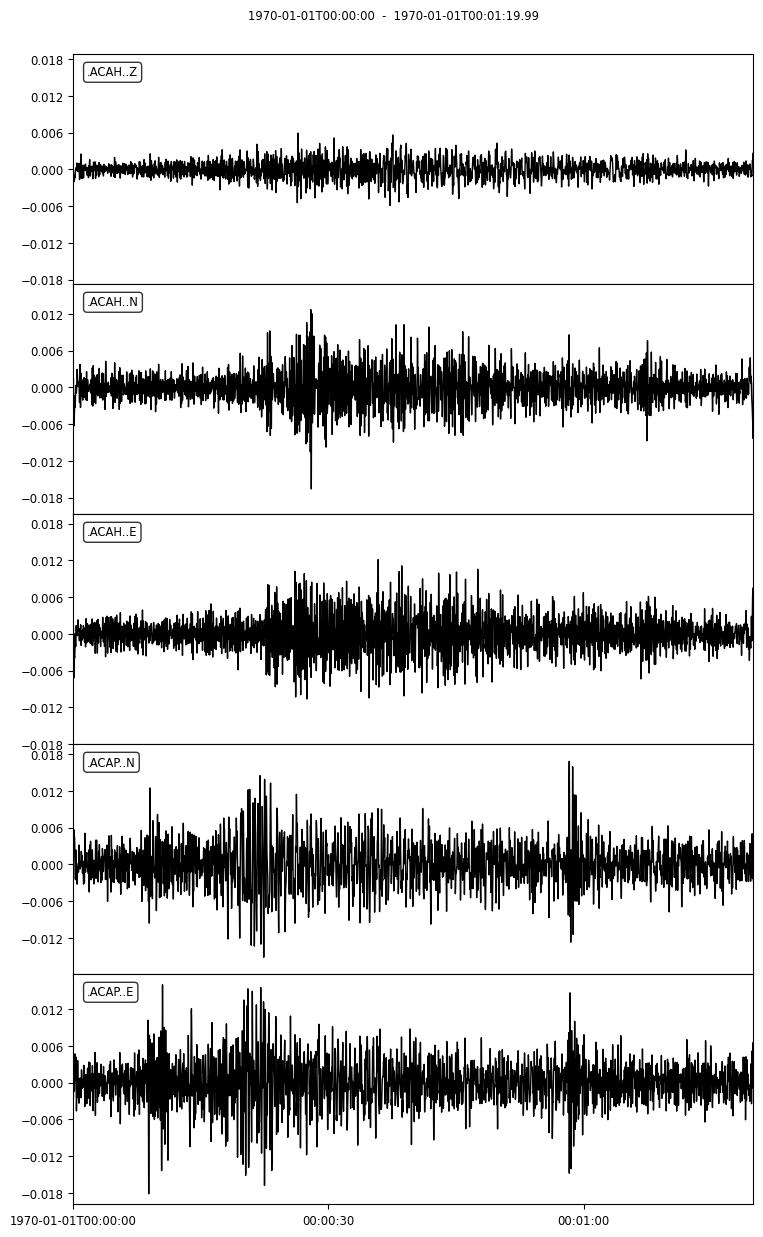

In [30]:
# plot the first 5 traces in the stack
lf.totstk[0:5].plot();

_Note that after stacking we've changed the channel naming conventions._ 

So now 'E' is for eastward velocities, 'N' is for northward velocities, and 'Z' is for upward velocities.  This change in naming convention is done by the function lf.replace_channels.

In [37]:
# note the first channel name
print('The first trace\'s channel, at station {:s}, is {:s}'.format(lf.totstk[0].stats.station,lf.totstk[0].stats.channel))

# and note what it was before
oldchan=np.array(list(lf.data.keys()))
oldchan=oldchan[np.array([lf.totstk[0].stats.station in vl for vl in oldchan])]
print('Even though the channels denoted in the seismograms were',oldchan)

The first trace's channel, at station ACAH, is E
Even though the channels denoted in the seismograms were ['ACAH.HHE' 'ACAH.HHN' 'ACAH.HHZ']


### 6. Note or choose the weighting in the stack

The function stack_by_group averages the _normalized_ traces in lf.data with a specified weighting.

The default weighting is 'even': each of the normalized traces is weighted the same in the averaging.  Each is given a weight $1/N_{ev}$, where $N_{ev}$ is the number of LFEs.

In [38]:
# to choose the weighting, specify the argument 'weighting'
lf.stack_by_group(weighting='even')

Alternatively, you can specify a weighting 'over_max', so that intervals with large amplitudes are weighted _less_ in the stack.  In this case, the weight for each interval is proportional to lf.data_norm/lf.data_max.  That makes sense if you think that most intervals are dominated by noise; downweighting large-amplitude intervals should then downweight the noise.

However, we may also wish to _upweight_ intervals when that have large-amplitude LFEs.  There is thus also an option to multiply each weight from 'even' or 'over_max' by an estimated LFE amplitude or moment.  To do this, we specify a weighting of 'even_with_amp' or 'over_max_with_amp'.  However, that will only work if we have a per-event (not per-station) amplitude estimate.  Such amplitudes must be saved in lf.evamp.  Notes on one approach to estimating them are in a later notebook.

### 7. Pick the arrivals and note stations with good SNR

We'll also want to know where in the traces the LFEs are recorded.  And as you'll note from the plots above, many of the stacks are dominated by noise.  We don't really want to analyse them. 

The function pick_stacks identifies the interval in each trace with the highest power, as summed over the two horizontal components.  It notes the beginning and end of this highest-power interval with tr.stats.t0 and tr.stats.t1.

And it computes the signal to noise power ratio for that window: comparing the few seconds with highest power with the few seconds before that.  Stations SNR power ratios above a specified value (minsnr) are listed in lf.stns.

In [41]:
# stacks we start with, including those with low SNR
print('We begin with stacks at {:d} station-channel pairs'.format(len(lf.totstk)))

We begin with stacks at 138 station-channel pairs


We still have stacks at 138 station-channel pairs
But only 5 stations have SNR larger than the specified minimum
The LFE signal in one trace starts 56.9s after the start time

All the picks:  {'ACAH': np.float64(25.51), 'ACAP': np.float64(19.1), 'AGBE': np.float64(55.67), 'AMAC': np.float64(33.05), 'ATOT': np.float64(54.06), 'BUCU': np.float64(31.82), 'CARR': np.float64(27.61), 'CASA': np.float64(32.160000000000004), 'CEME': np.float64(56.89), 'CIEN': np.float64(75.59), 'COAC': np.float64(41.5), 'EL40': np.float64(57.33), 'ELPO': np.float64(44.56), 'ESTA': np.float64(69.31), 'HUIT': np.float64(47.65), 'IXCA': np.float64(8.3), 'MAXE': np.float64(64.85), 'MAZA': np.float64(75.59), 'NOGA': np.float64(36.82), 'OCOT': np.float64(33.29), 'PABL': np.float64(4.4), 'PALM': np.float64(31.54), 'PETA': np.float64(31.11), 'PLAT': np.float64(45.69), 'PLAY': np.float64(33.03), 'PLLI': np.float64(33.35), 'PUIX': np.float64(38.88), 'QUEM': np.float64(55.28), 'RIVI': np.float64(28.35), 'SABI': np.float6

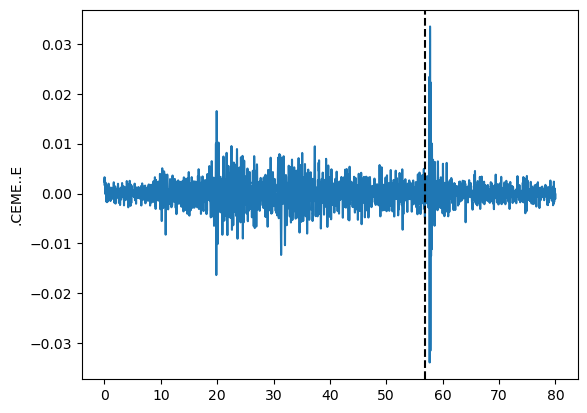

In [54]:
# pick the max power times on lf.totstk
lf.pick_stacks(wlen=[0,4],minsnr=10)

# note that some are discarded
print('We still have stacks at {:d} station-channel pairs'.format(len(lf.totstk)))
print('But only {:d} stations have SNR larger than the specified minimum'.format(len(lf.stns_stack)))

# the picking saves the start time of the window with highest power in tr.stats.t0
tr=lf.totstk.select(station=lf.stns_stack[0])[0]
print('The LFE signal in one trace starts {:0.1f}s after the start time'.format(tr.stats.t0))

plt.plot(tr.times(),tr.data);
plt.axvline(tr.stats.t0,color='k',linestyle='--');
plt.ylabel(tr.get_id())

# the pick times are also noted in lf.stack_picks
# one pick per station, not per channel
# all times are times since the start time of the trace
print('\nAll the picks: ',lf.stackpicks)

### 8. Plot the stacks

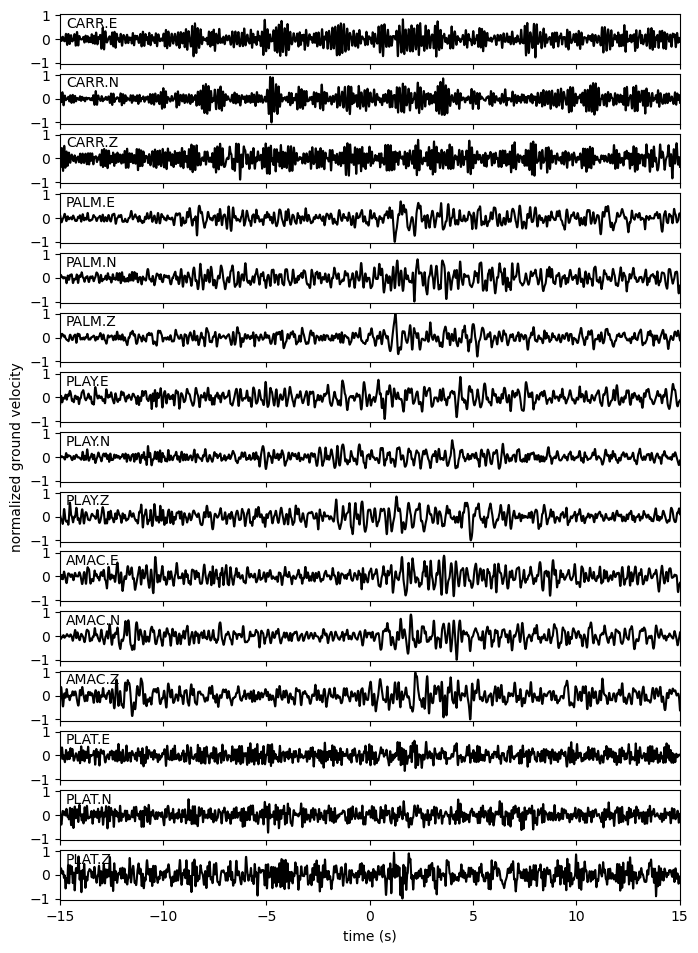

In [60]:
# now we can plot the stacks
# plot the average of all LFEs by specifying stype='all'
# Ns is the maximum number of stations to plot
lf.plot_stacks(stype='all',Ns=5)

### 9. Note the bootstrapped stacks

When we stacked the data using lf.stack_by_group, we also created a few more stacks by selecting random subsets of the data.  The goal here is see how much the results could vary if instead of using all the LFEs, we use a random subset.

So lf.totstk, described above, includes stacks of all events, but lf.totstkb includes 10 different stacks, created by stacking 10 different subsets of the data. 

In [62]:
# lf.totstkb is a dictionary, with one entry per station-channel pair
kys=np.array(list(lf.totstkb.keys()))
print('The bootstrapped stack dictionary contains bootstrapped stacks for {:d} station-channel pairs:'.format(kys.size))

print(kys)

The bootstrapped stack dictionary contains bootstrapped stacks for 138 station-channel pairs
['ACAH.E' 'ACAH.N' 'ACAH.Z' 'ACAP.E' 'ACAP.N' 'ACAP.Z' 'AGBE.E' 'AGBE.N'
 'AGBE.Z' 'AMAC.E' 'AMAC.N' 'AMAC.Z' 'ATOT.E' 'ATOT.N' 'ATOT.Z' 'BUCU.E'
 'BUCU.N' 'BUCU.Z' 'CARR.E' 'CARR.N' 'CARR.Z' 'CASA.E' 'CASA.N' 'CASA.Z'
 'CEME.E' 'CEME.N' 'CEME.Z' 'CIEN.E' 'CIEN.N' 'CIEN.Z' 'COAC.E' 'COAC.N'
 'COAC.Z' 'EL40.E' 'EL40.N' 'EL40.Z' 'ELPO.E' 'ELPO.N' 'ELPO.Z' 'ESTA.E'
 'ESTA.N' 'ESTA.Z' 'HUIT.E' 'HUIT.N' 'HUIT.Z' 'IXCA.E' 'IXCA.N' 'IXCA.Z'
 'MAXE.E' 'MAXE.N' 'MAXE.Z' 'MAZA.E' 'MAZA.N' 'MAZA.Z' 'NOGA.E' 'NOGA.N'
 'NOGA.Z' 'OCOT.E' 'OCOT.N' 'OCOT.Z' 'PABL.E' 'PABL.N' 'PABL.Z' 'PALM.E'
 'PALM.N' 'PALM.Z' 'PETA.E' 'PETA.N' 'PETA.Z' 'PLAT.E' 'PLAT.N' 'PLAT.Z'
 'PLAY.E' 'PLAY.N' 'PLAY.Z' 'PLLI.E' 'PLLI.N' 'PLLI.Z' 'PUIX.E' 'PUIX.N'
 'PUIX.Z' 'QUEM.E' 'QUEM.N' 'QUEM.Z' 'RIVI.E' 'RIVI.N' 'RIVI.Z' 'SABI.E'
 'SABI.N' 'SABI.Z' 'SAFE.E' 'SAFE.N' 'SAFE.Z' 'SAGR.E' 'SAGR.N' 'SAGR.Z'
 'SATA.E' 'SATA.N' 'SATA.Z' 'TE

Stack with all events:  .CIEN..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.990000Z | 100.0 Hz, 8000 samples

There are bootstrapped stacks in each column:  (8000, 10)


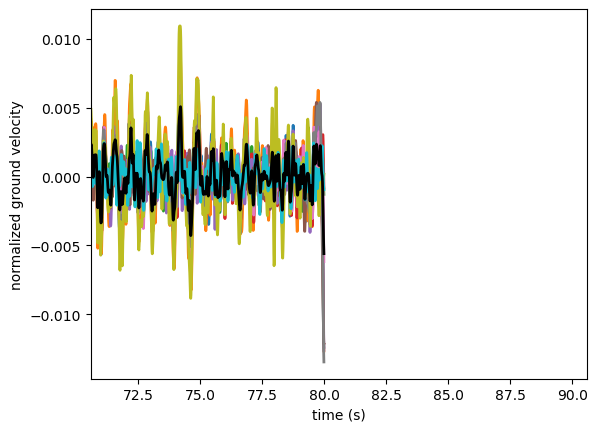

In [66]:
# let's look at the bootstrapped stacks for one station with good SNR
stn=np.random.choice(lf.stns_stack,1)[0]
# on the east component
chn='E'

# the trace with all the events
tr=lf.totstk.select(channel=chn,station=stn)[0]
print('Stack with all events: ',tr)

# the bootstrapped stacks
stkb=lf.totstkb['.'.join([stn,chn])]
print('\nThere are bootstrapped stacks in each column: ',stkb.shape)

plt.plot(tr.times(),stkb,linewidth=2,label='bootstrapped');
plt.plot(tr.times(),tr.data,color='k',linewidth=2,label='full stack');
plt.xlim(np.array([-5,15])+tr.stats.t0);
plt.xlabel('time (s)');
plt.ylabel('normalized ground velocity');